# 05. Plotting

Unified plotting notebook to get consistent plots across different models and datasets for comparison.

## Set-up

### Imports

In [1]:
import pylbsr.notebooks
import pylbsr.misc

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml
from pathlib import Path
import json
from PIL import Image

import torch
from parnet_demo_utils import torch_sparse_to_dense

### Initialization

In [3]:
_notebook_name = "05_comparison_plots.ipynb"
_notebook_path = f"notebooks/globalclip-head/{_notebook_name}"

pylbsr.notebooks.enable_cell_timing_metadata(show=True)
logger = pylbsr.misc.init_logger(_notebook_name)
PROJECT_DIR = pylbsr.notebooks.find_project_root_from_notebook_path(_notebook_path)
logger.info(f"Project directory: {PROJECT_DIR}")

#RUNS_DIR = PROJECT_DIR / "results" / "globalclip-head" / "training"
RUNS_DIR = Path('/mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training') #hardcode for accesing the current results we already have
FIGURES_DIR = PROJECT_DIR / "results" / "globalclip-head" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

[17:28:38] INFO - Project directory: /mnt/storage1/workspace/csainz/parnet--globalclip-head


⏱ 0.01 s (00:00:00)


### Define helper functions

In [4]:
def load_loss_curve(run_name):
    """Load epoch-level loss curves from a run's metrics.csv."""
    run_dir = RUNS_DIR / run_name
    csv_path = sorted((run_dir / "csv_logs").glob("version_*/metrics.csv"))[-1]
    df = pd.read_csv(csv_path)
    val   = df[["epoch", "val/loss"]].dropna(subset=["val/loss"])
    train = df[["epoch", "train/loss_eCLIP_epoch"]].dropna(subset=["train/loss_eCLIP_epoch"])
    return val.merge(train, on="epoch")

def load_test_eval(run_name):
    """Load final Pearson/Spearman from a run's test_evaluation.yaml."""
    eval_path = RUNS_DIR / run_name / "test_evaluation.yaml"
    if not eval_path.exists():
        return None
    return yaml.safe_load(eval_path.read_text())

def short_label(run_name):
    """Strip common prefix for cleaner plot labels."""
    return run_name.replace("parnet.7m-0.0.", "").replace(".globalclip-lysate-noNHS", "")

⏱ 0.00 s (00:00:00)


In [19]:
# ── Count-coverage quartile helpers ──────────────────────────────────────────────────
# NOTE: This uses PER-SEQUENCE correlations loaded from the .npy files saved by 
#       04_evaluate_runs.ipynb. Each sequence gets a single Pearson/Spearman correlation.
#       We bin sequences by their total count coverage.

N_QUANTILES = 4
QUARTILE_LABELS = ["Q1 (low)", "Q2", "Q3", "Q4 (high)"]
_QUARTILE_COLORS = plt.cm.tab10.colors

# Font sizes for better readability
FONT_SIZES = {
    'title': 16,
    'axis_label': 14,
    'tick_label': 11,
    'legend': 11,
    'suptitle': 17,
}


def load_test_counts_for_run(run_name):
    """Total signal (count coverage) per test-set sequence, using whichever
    dataset (raw/filtered) the run was trained on."""
    data_path = _filtered_path if ".filtered." in run_name else _raw_path
    return total_signals(data_path, split="test")


def load_test_correlations(run_name):
    """Load per-sequence Pearson/Spearman correlations from the .npy files
    saved by 04_evaluate_runs.ipynb.
    
    Returns:
        pearson: array of per-sequence Pearson correlations (shape: n_sequences,)
        spearman: array of per-sequence Spearman correlations (shape: n_sequences,)
    """
    pearson_path = RUNS_DIR / run_name / "test_pearson_scores.npy"
    spearman_path = RUNS_DIR / run_name / "test_spearman_scores.npy"
    
    if not pearson_path.exists() or not spearman_path.exists():
        logger.warning(
            f"{run_name}: missing .npy files with per-sequence correlations. "
            "Expected: test_pearson_scores.npy, test_spearman_scores.npy"
        )
        return None
    
    pearson = np.load(pearson_path)
    spearman = np.load(spearman_path)
    return pearson, spearman


def build_quartile_df(run_name):
    """Bin test-set sequences into count-coverage quartiles and attach each
    sequence's per-sequence Pearson/Spearman correlation. Returns a DataFrame
    with columns [count, quartile, pearson, spearman], or None if the
    correlations aren't available for this run.
    
    Each row in the DataFrame corresponds to one test sequence.
    """
    counts = load_test_counts_for_run(run_name)
    corr = load_test_correlations(run_name)
    if corr is None:
        return None
    pearson, spearman = corr

    n = min(len(counts), len(pearson), len(spearman))
    if len({len(counts), len(pearson), len(spearman)}) > 1:
        logger.warning(
            f"{run_name}: length mismatch (counts={len(counts)}, "
            f"pearson={len(pearson)}, spearman={len(spearman)}) — truncating to {n}"
        )
    counts, pearson, spearman = counts[:n], pearson[:n], spearman[:n]

    # Bin sequences by count coverage quartile
    quartile_idx = pd.qcut(counts, N_QUANTILES, labels=False, duplicates="drop")
    return pd.DataFrame({
        "count": counts,
        "quartile": quartile_idx,
        "pearson": pearson,
        "spearman": spearman,
    })


def plot_quartile_boxplot(ax, run_dict, metric="pearson", title=None):
    """Grouped box plots of per-sequence correlation (`metric`), split by
    count-coverage quartile. One color per run, one box per (run, quartile).
    """
    dfs = {label: build_quartile_df(run) for label, run in run_dict.items()}
    dfs = {label: df for label, df in dfs.items() if df is not None}
    n_runs = len(dfs)

    if n_runs == 0:
        ax.set_title(f"{title or metric} (no data)", fontsize=FONT_SIZES['title'])
        return

    width = 0.8 / n_runs
    x_base = np.arange(N_QUANTILES)

    for i, (label, df) in enumerate(dfs.items()):
        data_per_q = [df.loc[df["quartile"] == q, metric].values for q in range(N_QUANTILES)]
        pos = x_base + (i - (n_runs - 1) / 2) * width
        bp = ax.boxplot(data_per_q, positions=pos, widths=width * 0.85,
                         patch_artist=True, showfliers=False)
        color = _QUARTILE_COLORS[i % len(_QUARTILE_COLORS)]
        for box in bp["boxes"]:
            box.set_facecolor(color)
            box.set_alpha(0.6)
            box.set_edgecolor(color)
        for key in ("whiskers", "caps"):
            for line in bp[key]:
                line.set_color(color)
        for median in bp["medians"]:
            median.set_color("black")
        ax.plot([], [], color=color, linewidth=8, alpha=0.6, label=label)

    ax.set_xticks(x_base)
    ax.set_xticklabels(QUARTILE_LABELS, fontsize=FONT_SIZES['tick_label'])
    ax.set_xlabel("Count-coverage quartile (test set)", fontsize=FONT_SIZES['axis_label'])
    ax.set_ylabel(f"{metric.capitalize()} correlation", fontsize=FONT_SIZES['axis_label'])
    if title:
        ax.set_title(title, fontsize=FONT_SIZES['title'])
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.legend(loc="best", fontsize=FONT_SIZES['legend'], frameon=False)

⏱ 0.00 s (00:00:00)


### Define groups for comparison

In [28]:
# Section 1: Filtered vs raw (unfreeze_last_2, ep50)
RUNS_FILTERED_VS_RAW = {
    "filtered": "parnet.7m-0.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50",
    "raw":      "parnet.7m-0.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.raw.noctrl.ep50",
}

# Section 2: Unfreeze depth (all filtered, ep50)
RUNS_UNFREEZE_DEPTH = {
    "head":              "parnet.7m-0.0.head.globalclip-lysate-noNHS.filtered.noctrl.ep50",
    "unfreeze_last_2":   "parnet.7m-0.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50",
    "unfreeze_last_5":   "parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50",
}

# Section 3: model capacity - 7M (2 vs 5 layers) vs 21M (2 layers)
RUNS_MODEL_SIZE = {
    "7M unfreeze_2":  "parnet.7m-0.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50",
    "7M unfreeze_5":  "parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50",
    "21M unfreeze_2": "parnet.21m-5.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50",
}

# Section 4: models to compare for motif recovery (must have IG+metamotif already run)
MOTIF_COMPARISON_RUNS = {
    "head (7M)":        "parnet.7m-0.0.head.globalclip-lysate-noNHS.filtered.noctrl.ep50",
    "unfreeze_2 (7M)":  "parnet.7m-0.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50",
    "unfreeze_5 (7M)":  "parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50",
    "unfreeze_2 (21M)": "parnet.21m-5.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50",
}

# Final comparison:
# ── Combine all runs into a single dictionary with consistent labels ──────────────────
ALL_RUNS = {
    "head (7M)": "parnet.7m-0.0.head.globalclip-lysate-noNHS.filtered.noctrl.ep50",
    "unfreeze_2 (7M)": "parnet.7m-0.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50",
    "unfreeze_5 (7M)": "parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50",
    "unfreeze_2 (21M)": "parnet.21m-5.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50"
}

# Color palette for consistent model coloring
MODEL_COLORS = {
    "head (7M)": "#1f77b4",      # blue
    "unfreeze_2 (7M)": "#ff7f0e", # orange
    "unfreeze_5 (7M)": "#2ca02c", # green
    "unfreeze_2 (21M)": "#d62728" # red
}

# Line styles for filtered vs raw distinction
MODEL_LINESTYLES = {
    "head (7M)": "-",
    "unfreeze_2 (7M)": "-",
    "unfreeze_5 (7M)": "-",
    "unfreeze_2 (21M)": "-"
}

⏱ 0.00 s (00:00:00)


### Filepaths

In [8]:
_fp_cfg = yaml.safe_load((PROJECT_DIR / "config" / "filepaths.yaml").read_text())
_raw_path      = Path(_fp_cfg["global_clip"]["data_lysate_noNHS"])
_filtered_path = Path(_fp_cfg["global_clip"]["data_lysate_noNHS_filtered"])

⏱ 0.01 s (00:00:00)


## 1. Comparison plots

### 1.1 Raw vs. filtered

[16:03:01] INFO - Computing signal distributions...


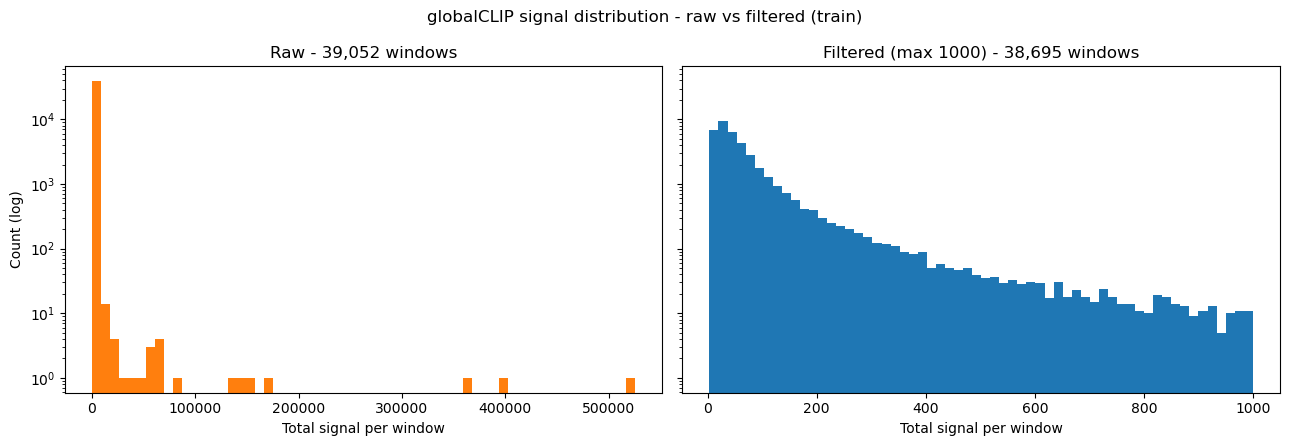

[16:03:22] INFO - Raw: max=525738, median=44
[16:03:22] INFO - Filtered: max=1000, median=43


⏱ 21.00 s (00:00:21)


In [ ]:
# ── Dataset distribution comparison (raw vs filtered) ──────────────────────────
def total_signals(data_path, split="train"):
    data = torch.load(data_path, mmap=True, weights_only=False)
    return np.array([
        torch_sparse_to_dense(s["outputs"]["globalCLIP"]).sum().item()
        for s in data[split]
    ])

logger.info("Computing signal distributions...")
sig_raw      = total_signals(_raw_path)
sig_filtered = total_signals(_filtered_path)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

axes[0].hist(sig_raw, bins=60, log=True, color="tab:orange")
axes[0].set_title(f"Raw - {len(sig_raw):,} windows")
axes[0].set_xlabel("Total signal per window")
axes[0].set_ylabel("Count (log)")

axes[1].hist(sig_filtered, bins=60, log=True, color="tab:blue")
axes[1].set_title(f"Filtered (max 1000) - {len(sig_filtered):,} windows")
axes[1].set_xlabel("Total signal per window")

plt.suptitle("globalCLIP signal distribution - raw vs filtered (train)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dataset_signal_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

logger.info(f"Raw: max={sig_raw.max():.0f}, median={np.median(sig_raw):.0f}")
logger.info(f"Filtered: max={sig_filtered.max():.0f}, median={np.median(sig_filtered):.0f}")

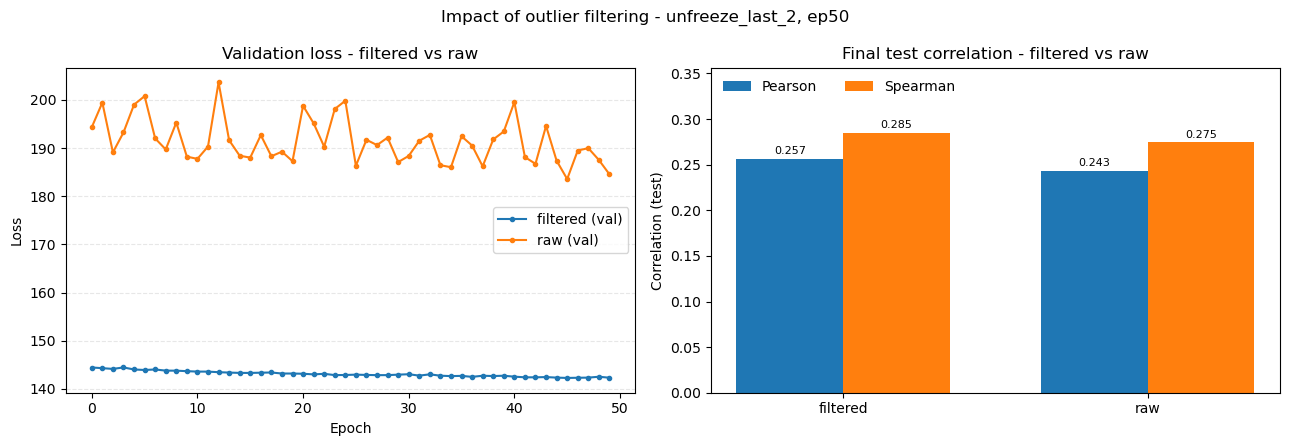

⏱ 0.47 s (00:00:00)


In [24]:
# ── Section 1: Filtered vs Raw ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Loss curves ────────────────────────────────────────────────────────────────
for label, run in RUNS_FILTERED_VS_RAW.items():
    try:
        df = load_loss_curve(run)
        axes[0].plot(df["epoch"], df["val/loss"], marker="o", markersize=3, label=f"{label} (val)")
    except (FileNotFoundError, IndexError):
        logger.warning(f"Missing loss data: {run}")

axes[0].set_title("Validation loss - filtered vs raw")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# ── Final Pearson/Spearman bars ────────────────────────────────────────────────
labels, pearson_vals, spearman_vals = [], [], []
for label, run in RUNS_FILTERED_VS_RAW.items():
    ev = load_test_eval(run)
    if ev:
        labels.append(label)
        pearson_vals.append(ev["pearson_mean"])
        spearman_vals.append(ev["spearman_mean"])

x = np.arange(len(labels))
w = 0.35
axes[1].bar(x - w/2, pearson_vals, w, label="Pearson")
axes[1].bar(x + w/2, spearman_vals, w, label="Spearman")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel("Correlation (test)")
axes[1].set_title("Final test correlation - filtered vs raw")
axes[1].set_ylim(0, max(pearson_vals + spearman_vals) * 1.25)
axes[1].legend(loc="upper left", ncol=2, frameon=False)

for i, (p, s) in enumerate(zip(pearson_vals, spearman_vals)):
    axes[1].text(i - w/2, p + 0.005, f"{p:.3f}", ha="center", fontsize=8)
    axes[1].text(i + w/2, s + 0.005, f"{s:.3f}", ha="center", fontsize=8)

plt.suptitle("Impact of outlier filtering - unfreeze_last_2, ep50")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparison_filtered_vs_raw.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.2 Unfreeze depth

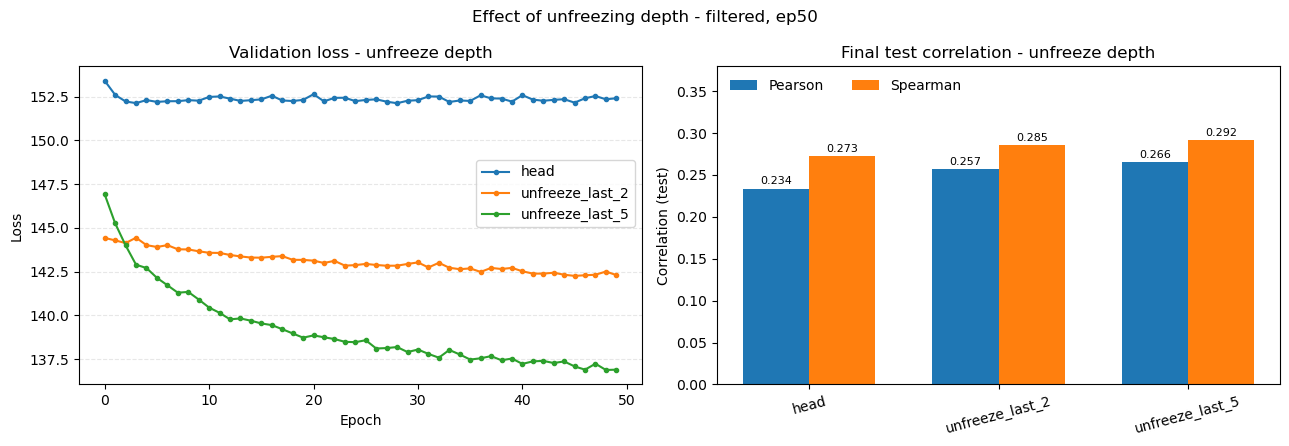

⏱ 0.81 s (00:00:00)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Loss curves ────────────────────────────────────────────────────────────────
for label, run in RUNS_UNFREEZE_DEPTH.items():
    try:
        df = load_loss_curve(run)
        axes[0].plot(df["epoch"], df["val/loss"], marker="o", markersize=3, label=label)
    except (FileNotFoundError, IndexError):
        logger.warning(f"Missing loss data: {run}")

axes[0].set_title("Validation loss - unfreeze depth")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(loc="center right", bbox_to_anchor=(1.0, 0.6))
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# ── Final Pearson/Spearman bars ────────────────────────────────────────────────
labels, pearson_vals, spearman_vals = [], [], []
for label, run in RUNS_UNFREEZE_DEPTH.items():
    ev = load_test_eval(run)
    if ev:
        labels.append(label)
        pearson_vals.append(ev["pearson_mean"])
        spearman_vals.append(ev["spearman_mean"])

x = np.arange(len(labels))
w = 0.35
axes[1].bar(x - w/2, pearson_vals, w, label="Pearson")
axes[1].bar(x + w/2, spearman_vals, w, label="Spearman")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=15)
axes[1].set_ylabel("Correlation (test)")
axes[1].set_title("Final test correlation - unfreeze depth")
axes[1].set_ylim(0, max(pearson_vals + spearman_vals) * 1.3)
axes[1].legend(loc="upper left", ncol=2, frameon=False)
for i, (p, s) in enumerate(zip(pearson_vals, spearman_vals)):
    axes[1].text(i - w/2, p + 0.005, f"{p:.3f}", ha="center", fontsize=8)
    axes[1].text(i + w/2, s + 0.005, f"{s:.3f}", ha="center", fontsize=8)

plt.suptitle("Effect of unfreezing depth - filtered, ep50")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparison_unfreeze_depth.png", dpi=150, bbox_inches="tight")
plt.show()

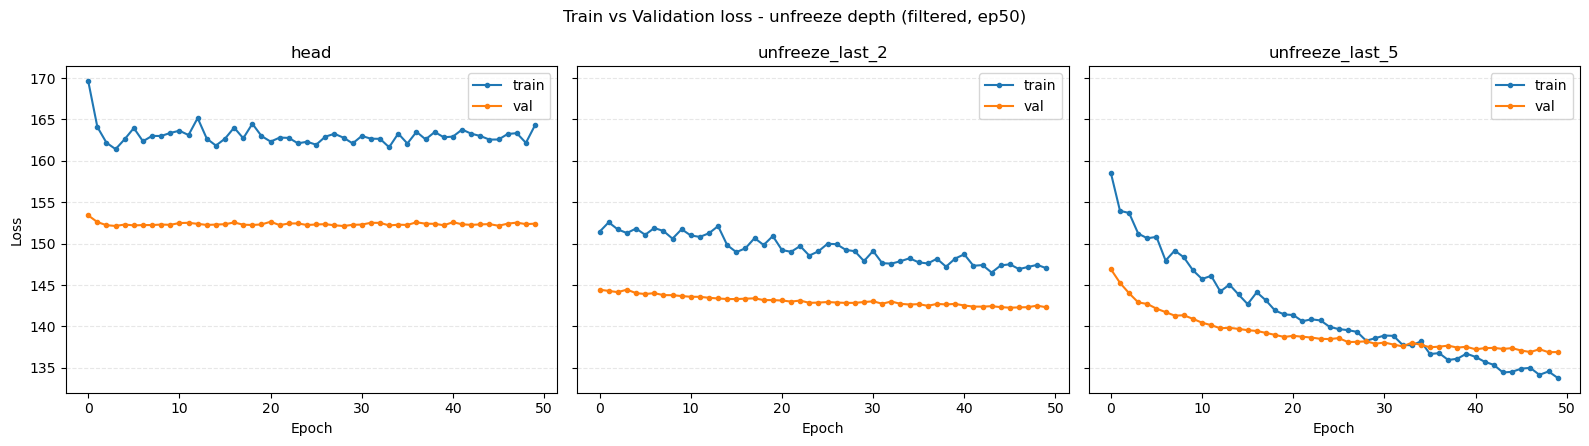

⏱ 0.66 s (00:00:00)


In [26]:
# ── Appendix: train + val loss for all unfreeze-depth models ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for ax, (label, run) in zip(axes, RUNS_UNFREEZE_DEPTH.items()):
    try:
        df = load_loss_curve(run)
        ax.plot(df["epoch"], df["train/loss_eCLIP_epoch"], marker="o", markersize=3, label="train", color="tab:blue")
        ax.plot(df["epoch"], df["val/loss"], marker="o", markersize=3, label="val", color="tab:orange")
        ax.set_title(label)
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(axis='y', alpha=0.3, linestyle='--')


    except (FileNotFoundError, IndexError):
        ax.set_title(f"{label} (missing)")
        logger.warning(f"Missing loss data: {run}")

axes[0].set_ylabel("Loss")

plt.suptitle("Train vs Validation loss - unfreeze depth (filtered, ep50)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "appendix_unfreeze_depth_train_val.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.3 Model size comparison (7M vs 21 M parameters)

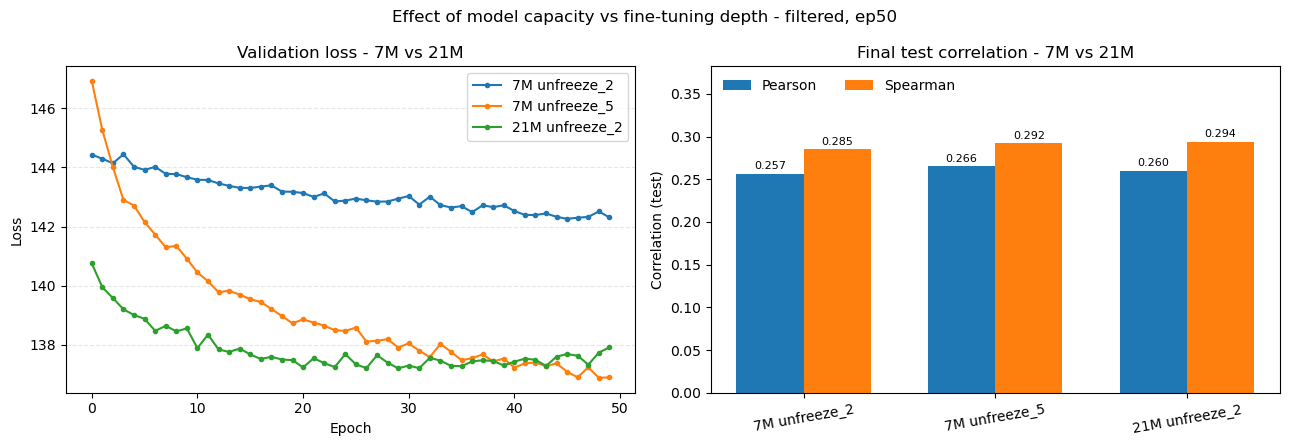

⏱ 0.48 s (00:00:00)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Loss curves ────────────────────────────────────────────────────────────────
for label, run in RUNS_MODEL_SIZE.items():
    try:
        df = load_loss_curve(run)
        axes[0].plot(df["epoch"], df["val/loss"], marker="o", markersize=3, label=label)
    except (FileNotFoundError, IndexError):
        logger.warning(f"Missing loss data: {run}")

axes[0].set_title("Validation loss - 7M vs 21M")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3, linestyle='--')


# ── Final Pearson/Spearman bars ────────────────────────────────────────────────
labels, pearson_vals, spearman_vals = [], [], []
for label, run in RUNS_MODEL_SIZE.items():
    ev = load_test_eval(run)
    if ev:
        labels.append(label)
        pearson_vals.append(ev["pearson_mean"])
        spearman_vals.append(ev["spearman_mean"])

x = np.arange(len(labels))
w = 0.35
axes[1].bar(x - w/2, pearson_vals, w, label="Pearson")
axes[1].bar(x + w/2, spearman_vals, w, label="Spearman")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=10)
axes[1].set_ylabel("Correlation (test)")
axes[1].set_title("Final test correlation - 7M vs 21M")
axes[1].set_ylim(0, max(pearson_vals + spearman_vals) * 1.3)
axes[1].legend(loc="upper left", ncol=2, frameon=False)
for i, (p, s) in enumerate(zip(pearson_vals, spearman_vals)):
    axes[1].text(i - w/2, p + 0.005, f"{p:.3f}", ha="center", fontsize=8)
    axes[1].text(i + w/2, s + 0.005, f"{s:.3f}", ha="center", fontsize=8)

plt.suptitle("Effect of model capacity vs fine-tuning depth - filtered, ep50")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparison_model_size.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.4 Complete summary table

In [ ]:
ALL_RUNS = {
    # filtered vs raw
    "unfreeze_2 | filtered | ep50": "parnet.7m-0.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50",
    "unfreeze_2 | raw | ep50":      "parnet.7m-0.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.raw.noctrl.ep50",
    # unfreeze depth (filtered)
    "head | filtered | ep50":       "parnet.7m-0.0.head.globalclip-lysate-noNHS.filtered.noctrl.ep50",
    "unfreeze_5 | filtered | ep50": "parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50",
    # model size
    "21M unfreeze_2 | filtered | ep50": "parnet.21m-5.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50",
}

rows = []
for label, run in ALL_RUNS.items():
    ev = load_test_eval(run)
    try:
        df = load_loss_curve(run)
        final_val_loss = df["val/loss"].iloc[-1]
        best_val_loss = df["val/loss"].min()
    except (FileNotFoundError, IndexError):
        final_val_loss = best_val_loss = np.nan
    rows.append({
        "run": label,
        "best_val_loss": round(best_val_loss, 2) if not np.isnan(best_val_loss) else "-",
        "final_val_loss": round(final_val_loss, 2) if not np.isnan(final_val_loss) else "-",
        "pearson": round(ev["pearson_mean"], 4) if ev else "-",
        "spearman": round(ev["spearman_mean"], 4) if ev else "-",
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

# save as CSV for the report
summary_df.to_csv(FIGURES_DIR / "master_summary_table.csv", index=False)
logger.info(f"Saved summary table → {FIGURES_DIR / 'master_summary_table.csv'}")

[20:04:40] INFO - Saved summary table → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/figures/master_summary_table.csv


                             run  best_val_loss  final_val_loss  pearson  spearman
    unfreeze_2 | filtered | ep50         142.26          142.31   0.2566    0.2852
         unfreeze_2 | raw | ep50         183.56          184.55   0.2432    0.2745
          head | filtered | ep50         152.12          152.41   0.2338    0.2729
    unfreeze_5 | filtered | ep50         136.89          136.90   0.2657    0.2920
21M unfreeze_2 | filtered | ep50         137.21          137.92   0.2603    0.2941
⏱ 0.11 s (00:00:00)


### 1.5 Motif comparison across models

In [ ]:
def get_motif_dir(run_name):
    return RUNS_DIR / run_name / "integrated_gradients" / "metamotif" / "aligned_motifs"

def get_rbp_matches(run_name):
    p = RUNS_DIR / run_name / "integrated_gradients" / "metamotif" / "rbp_matches.json"
    return json.loads(p.read_text()) if p.exists() else None

⏱ 0.00 s (00:00:00)


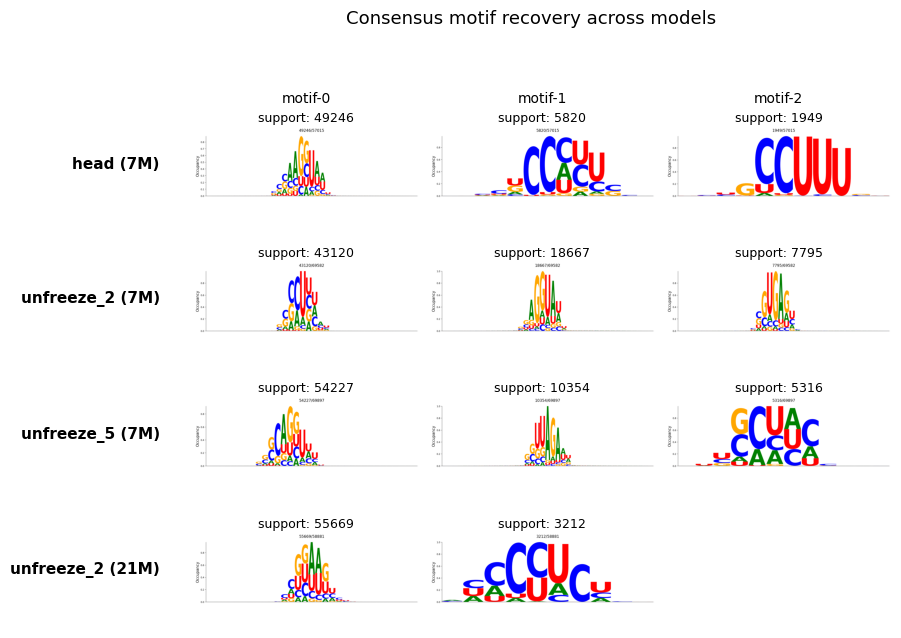

⏱ 1.16 s (00:00:01)


In [31]:
# ── Motif logo grid: one row per model ─────────────────────────────────────────
model_motifs = {}
for label, run in MOTIF_COMPARISON_RUNS.items():
    motif_dir = get_motif_dir(run)
    pngs = sorted(motif_dir.glob("motif-*.png")) if motif_dir.exists() else []
    model_motifs[label] = pngs

def get_support(png_path):
    """Read support count from the matching .tsv header line: '#support=N'."""
    tsv_path = png_path.with_suffix(".tsv")
    if not tsv_path.exists():
        return None
    first_line = tsv_path.read_text().splitlines()[0]
    return first_line.replace("#support=", "").strip()

max_motifs = max((len(p) for p in model_motifs.values()), default=0)
n_models = len(model_motifs)

if max_motifs == 0:
    logger.warning("No motif logos found — run IG+metamotif on the models first.")
else:
    fig, axes = plt.subplots(n_models, max_motifs,
                             figsize=(3.0 * max_motifs, 1.7 * n_models),
                             squeeze=False)
    for row, (label, pngs) in enumerate(model_motifs.items()):
        for col in range(max_motifs):
            ax = axes[row][col]
            ax.axis("off")
            if col < len(pngs):
                ax.imshow(Image.open(pngs[col]))
                support = get_support(pngs[col])
                if support:
                    ax.text(0.5, 1.05, f"support: {support}", transform=ax.transAxes,
                            ha="center", va="bottom", fontsize=9)
                if row == 0:
                    ax.set_title(f"motif-{col}", fontsize=10, pad=18)
            if col == 0:
                ax.text(-0.15, 0.5, label, transform=ax.transAxes,
                        ha="right", va="center", fontsize=11, fontweight="bold", rotation=0)

    plt.suptitle("Consensus motif recovery across models", y=1.02, fontsize=13)
    plt.subplots_adjust(hspace=0.15, wspace=0.05)
    plt.savefig(FIGURES_DIR / "motif_comparison_across_models.png", dpi=150, bbox_inches="tight")
    plt.show()

In [32]:
# ── RBP match summary across models ────────────────────────────────────────────
rows = []
for label, run in MOTIF_COMPARISON_RUNS.items():
    matches = get_rbp_matches(run)
    if matches is None:
        logger.warning(f"No rbp_matches.json for {label}")
        continue
    for motif, rbp_list in matches.items():
        # top RBP for each motif + whether it's discriminative (top PCC < 1.0)
        if not rbp_list:
            continue
        top = rbp_list[0]
        top3 = ", ".join(m["rbp"] for m in rbp_list[:3])
        rows.append({
            "model": label,
            "motif": motif,
            "top_rbp": top["rbp"],
            "top_pcc": top["pcc"],
            "discriminative": "yes" if top["pcc"] < 1.0 else "no (low-complexity)",
            "top_3_rbps": top3,
        })

rbp_summary = pd.DataFrame(rows)
print(rbp_summary.to_string(index=False))

rbp_summary.to_csv(FIGURES_DIR / "rbp_matches_across_models.csv", index=False)
logger.info(f"Saved RBP match summary → {FIGURES_DIR / 'rbp_matches_across_models.csv'}")

[20:11:45] INFO - Saved RBP match summary → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/figures/rbp_matches_across_models.csv


           model   motif      top_rbp  top_pcc discriminative                 top_3_rbps
       head (7M) motif-0        NFKB1   0.9229            yes       NFKB1, SRP54, ZRANB2
       head (7M) motif-1        RPO21   0.8636            yes        RPO21, SRSF5, RBM23
       head (7M) motif-2         TLR3   0.9292            yes          TLR3, ORB2, TIAL1
 unfreeze_2 (7M) motif-0        PTBP1   0.9151            yes  PTBP1, CTHT_0057680, PAP1
 unfreeze_2 (7M) motif-1        NFKB1   0.9800            yes NFKB1, SRP54, CTHT_0057680
 unfreeze_2 (7M) motif-2          SXL   0.9840            yes    SXL, CTHT_0057680, PAP1
 unfreeze_5 (7M) motif-0 CTHT_0057680   0.9646            yes   CTHT_0057680, PAP1, RBMX
 unfreeze_5 (7M) motif-1        KHSRP   0.9578            yes      KHSRP, HNRNPA1, SRSF2
 unfreeze_5 (7M) motif-2         YBX1   0.8608            yes          YBX1, HEN1, SRSF3
unfreeze_2 (21M) motif-0        SRSF5   0.9129            yes  SRSF5, CTHT_0057680, PAP1
unfreeze_2 (21M) moti

## 2. Comparison plots with test set divided into quartiles

### 1.1 Filtered vs. Raw

[17:38:06] INFO - Computing signal distributions...


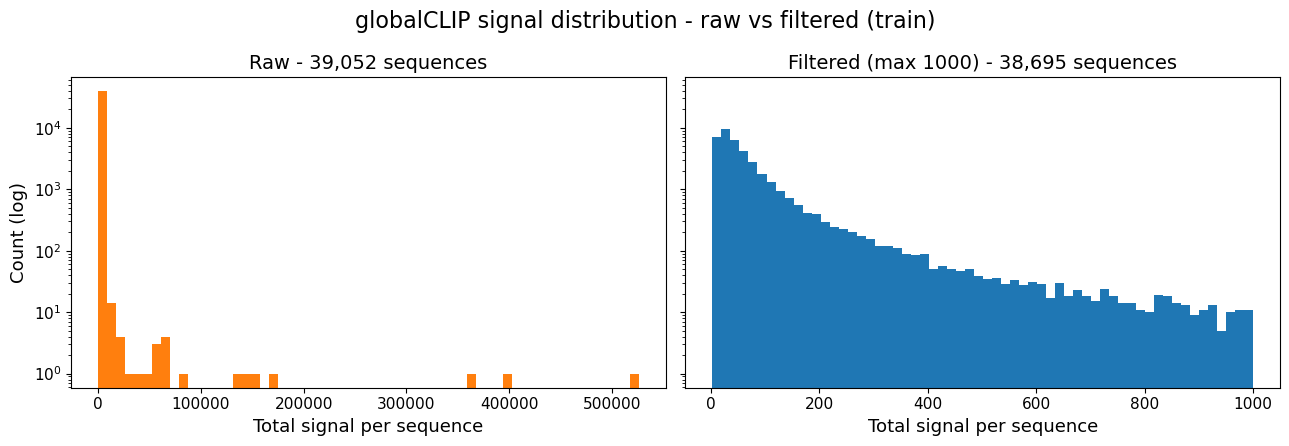

[17:38:24] INFO - Raw: max=525738, median=44
[17:38:24] INFO - Filtered: max=1000, median=43


⏱ 17.71 s (00:00:17)


In [16]:
# ── Dataset distribution comparison (raw vs filtered) ──────────────────────────────────
def total_signals(data_path, split="train"):
    """Compute total signal per sequence (sum of globalCLIP signal across all windows).
    Returns an array of total signal per sequence."""
    data = torch.load(data_path, mmap=True, weights_only=False)
    return np.array([
        torch_sparse_to_dense(s["outputs"]["globalCLIP"]).sum().item()
        for s in data[split]
    ])

logger.info("Computing signal distributions...")
sig_raw      = total_signals(_raw_path)
sig_filtered = total_signals(_filtered_path)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

axes[0].hist(sig_raw, bins=60, log=True, color="tab:orange")
axes[0].set_title(f"Raw - {len(sig_raw):,} sequences", fontsize=FONT_SIZES['title'])
axes[0].set_xlabel("Total signal per sequence", fontsize=FONT_SIZES['axis_label'])
axes[0].set_ylabel("Count (log)", fontsize=FONT_SIZES['axis_label'])
axes[0].tick_params(labelsize=FONT_SIZES['tick_label'])

axes[1].hist(sig_filtered, bins=60, log=True, color="tab:blue")
axes[1].set_title(f"Filtered (max 1000) - {len(sig_filtered):,} sequences", fontsize=FONT_SIZES['title'])
axes[1].set_xlabel("Total signal per sequence", fontsize=FONT_SIZES['axis_label'])
axes[1].tick_params(labelsize=FONT_SIZES['tick_label'])

plt.suptitle("globalCLIP signal distribution - raw vs filtered (train)", fontsize=FONT_SIZES['suptitle'])
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dataset_signal_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

logger.info(f"Raw: max={sig_raw.max():.0f}, median={np.median(sig_raw):.0f}")
logger.info(f"Filtered: max={sig_filtered.max():.0f}, median={np.median(sig_filtered):.0f}")

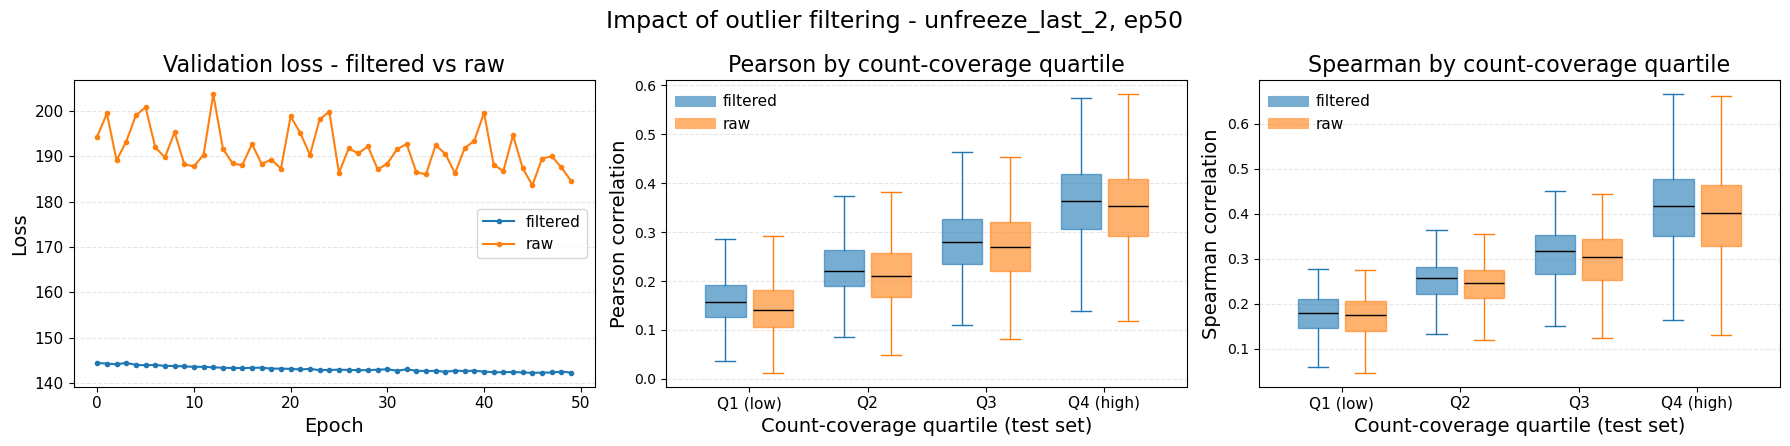

⏱ 34.30 s (00:00:34)


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# ── Loss curves ────────────────────────────────────────────────────────────────
for label, run in RUNS_FILTERED_VS_RAW.items():
    try:
        df = load_loss_curve(run)
        axes[0].plot(df["epoch"], df["val/loss"], marker="o", markersize=3, label=label)
    except (FileNotFoundError, IndexError):
        logger.warning(f"Missing loss data: {run}")

axes[0].set_title("Validation loss - filtered vs raw", fontsize=FONT_SIZES['title'])
axes[0].set_xlabel("Epoch", fontsize=FONT_SIZES['axis_label'])
axes[0].set_ylabel("Loss", fontsize=FONT_SIZES['axis_label'])
axes[0].tick_params(labelsize=FONT_SIZES['tick_label'])
axes[0].legend(fontsize=FONT_SIZES['legend'])
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# ── Per-quartile Pearson / Spearman box plots ────────────────────────────────
plot_quartile_boxplot(axes[1], RUNS_FILTERED_VS_RAW, metric="pearson",
                       title="Pearson by count-coverage quartile")
plot_quartile_boxplot(axes[2], RUNS_FILTERED_VS_RAW, metric="spearman",
                       title="Spearman by count-coverage quartile")

plt.suptitle("Impact of outlier filtering - unfreeze_last_2, ep50", fontsize=FONT_SIZES['suptitle'])
plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparison_filtered_vs_raw.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.2 Unfreeze depth

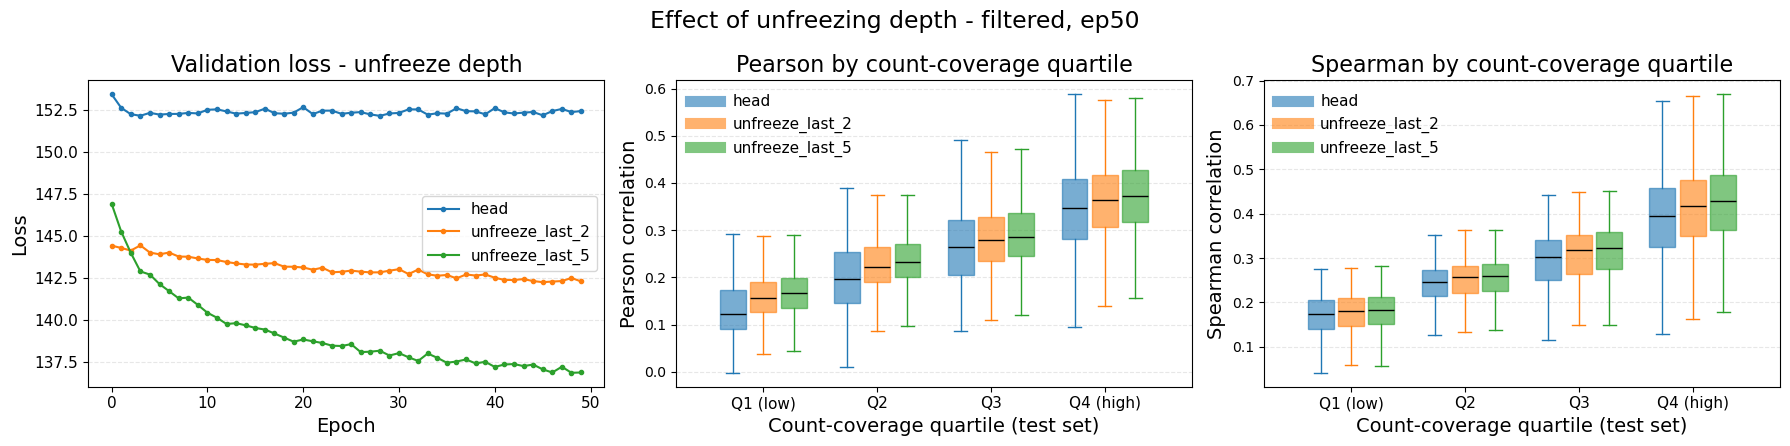

⏱ 49.74 s (00:00:49)


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# ── Loss curves ────────────────────────────────────────────────────────────────
for label, run in RUNS_UNFREEZE_DEPTH.items():
    try:
        df = load_loss_curve(run)
        axes[0].plot(df["epoch"], df["val/loss"], marker="o", markersize=3, label=label)
    except (FileNotFoundError, IndexError):
        logger.warning(f"Missing loss data: {run}")

axes[0].set_title("Validation loss - unfreeze depth", fontsize=FONT_SIZES['title'])
axes[0].set_xlabel("Epoch", fontsize=FONT_SIZES['axis_label'])
axes[0].set_ylabel("Loss", fontsize=FONT_SIZES['axis_label'])
axes[0].tick_params(labelsize=FONT_SIZES['tick_label'])
axes[0].legend(fontsize=FONT_SIZES['legend'])
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# ── Per-quartile Pearson / Spearman box plots ────────────────────────────────
plot_quartile_boxplot(axes[1], RUNS_UNFREEZE_DEPTH, metric="pearson",
                       title="Pearson by count-coverage quartile")
plot_quartile_boxplot(axes[2], RUNS_UNFREEZE_DEPTH, metric="spearman",
                       title="Spearman by count-coverage quartile")

plt.suptitle("Effect of unfreezing depth - filtered, ep50", fontsize=FONT_SIZES['suptitle'])
plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparison_unfreeze_depth.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.3 Model size comparison (7M vs. 21M)

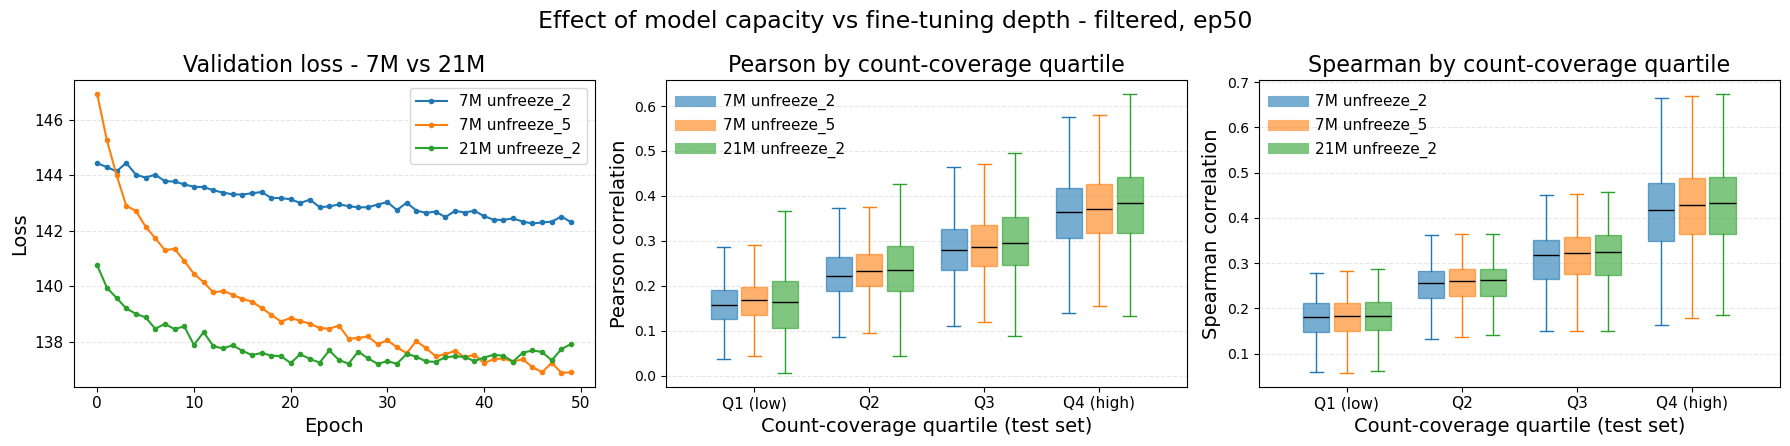

⏱ 48.48 s (00:00:48)


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# ── Loss curves ────────────────────────────────────────────────────────────────
for label, run in RUNS_MODEL_SIZE.items():
    try:
        df = load_loss_curve(run)
        axes[0].plot(df["epoch"], df["val/loss"], marker="o", markersize=3, label=label)
    except (FileNotFoundError, IndexError):
        logger.warning(f"Missing loss data: {run}")

axes[0].set_title("Validation loss - 7M vs 21M", fontsize=FONT_SIZES['title'])
axes[0].set_xlabel("Epoch", fontsize=FONT_SIZES['axis_label'])
axes[0].set_ylabel("Loss", fontsize=FONT_SIZES['axis_label'])
axes[0].tick_params(labelsize=FONT_SIZES['tick_label'])
axes[0].legend(fontsize=FONT_SIZES['legend'])
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# ── Per-quartile Pearson / Spearman box plots ────────────────────────────────
plot_quartile_boxplot(axes[1], RUNS_MODEL_SIZE, metric="pearson",
                       title="Pearson by count-coverage quartile")
plot_quartile_boxplot(axes[2], RUNS_MODEL_SIZE, metric="spearman",
                       title="Spearman by count-coverage quartile")

plt.suptitle("Effect of model capacity vs fine-tuning depth - filtered, ep50", fontsize=FONT_SIZES['suptitle'])
plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparison_model_size.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.4 Combined figure: unfreeze depth + model size

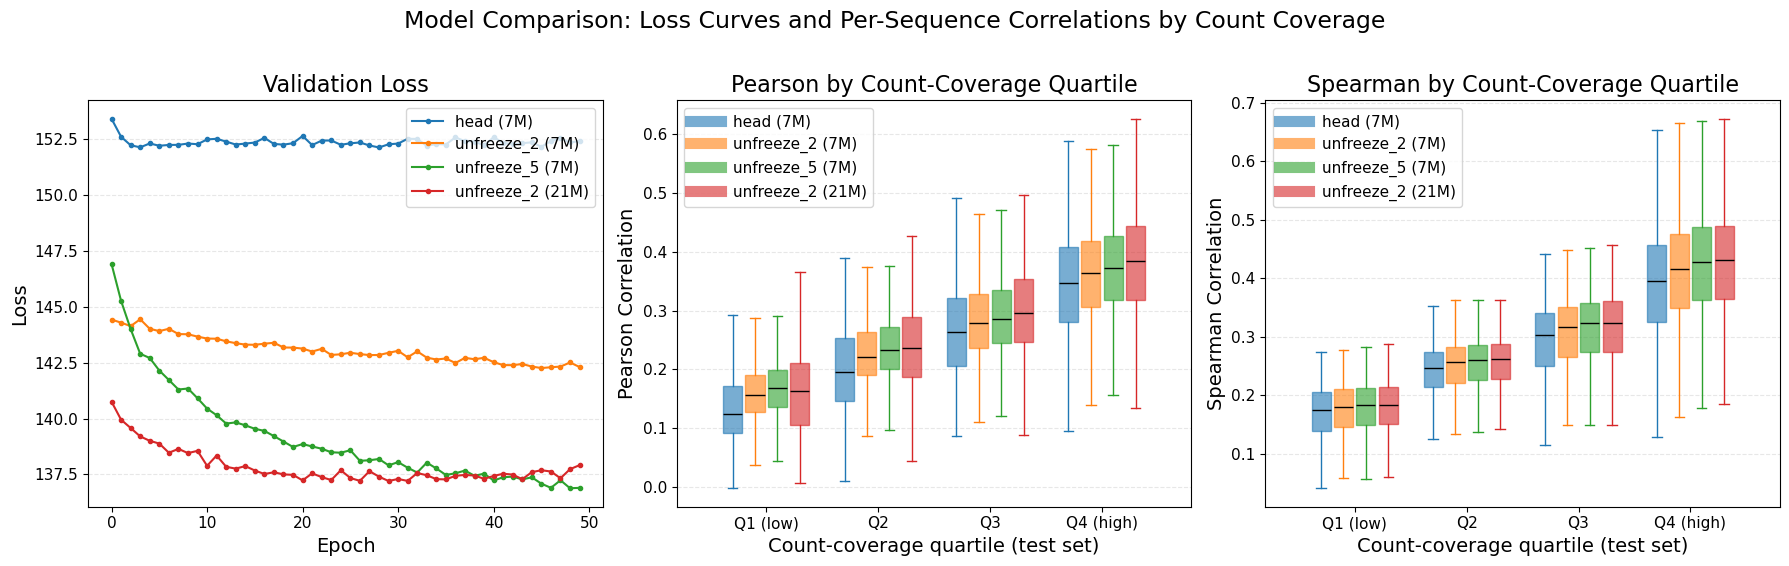

⏱ 32.73 s (00:00:32)


In [29]:
# ── Final figure: Loss curves + Pearson box plots + Spearman box plots ──────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# ── Panel 1: Validation loss curves (all models together) ──────────────────────────
for label, run in ALL_RUNS.items():
    try:
        df = load_loss_curve(run)
        color = MODEL_COLORS.get(label, "gray")
        linestyle = MODEL_LINESTYLES.get(label, "-")
        axes[0].plot(df["epoch"], df["val/loss"], 
                     marker="o", markersize=3, 
                     color=color, linestyle=linestyle,
                     label=label)
    except (FileNotFoundError, IndexError):
        logger.warning(f"Missing loss data: {run}")

axes[0].set_title("Validation Loss", fontsize=FONT_SIZES['title'])
axes[0].set_xlabel("Epoch", fontsize=FONT_SIZES['axis_label'])
axes[0].set_ylabel("Loss", fontsize=FONT_SIZES['axis_label'])
axes[0].tick_params(labelsize=FONT_SIZES['tick_label'])
axes[0].legend(fontsize=FONT_SIZES['legend'], frameon=True, loc="upper right")
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# ── Panel 2: Pearson box plots (all models together) ────────────────────────────────
# Build all DataFrames first
all_pearson_dfs = {}
for label, run in ALL_RUNS.items():
    df = build_quartile_df(run)
    if df is not None:
        all_pearson_dfs[label] = df

if all_pearson_dfs:
    n_runs = len(all_pearson_dfs)
    width = 0.8 / n_runs
    x_base = np.arange(N_QUANTILES)
    
    for i, (label, df) in enumerate(all_pearson_dfs.items()):
        data_per_q = [df.loc[df["quartile"] == q, "pearson"].values for q in range(N_QUANTILES)]
        pos = x_base + (i - (n_runs - 1) / 2) * width
        color = MODEL_COLORS.get(label, "gray")
        
        bp = axes[1].boxplot(data_per_q, positions=pos, widths=width * 0.85,
                             patch_artist=True, showfliers=False)
        for box in bp["boxes"]:
            box.set_facecolor(color)
            box.set_alpha(0.6)
            box.set_edgecolor(color)
        for key in ("whiskers", "caps"):
            for line in bp[key]:
                line.set_color(color)
        for median in bp["medians"]:
            median.set_color("black")
        axes[1].plot([], [], color=color, linewidth=8, alpha=0.6, label=label)
    
    axes[1].set_xticks(x_base)
    axes[1].set_xticklabels(QUARTILE_LABELS, fontsize=FONT_SIZES['tick_label'])
    axes[1].set_xlabel("Count-coverage quartile (test set)", fontsize=FONT_SIZES['axis_label'])
    axes[1].set_ylabel("Pearson Correlation", fontsize=FONT_SIZES['axis_label'])
    axes[1].set_title("Pearson by Count-Coverage Quartile", fontsize=FONT_SIZES['title'])
    axes[1].tick_params(labelsize=FONT_SIZES['tick_label'])
    axes[1].grid(axis='y', alpha=0.3, linestyle='--')
    axes[1].legend(fontsize=FONT_SIZES['legend'], frameon=True, loc="best")
else:
    axes[1].set_title("Pearson by Count-Coverage Quartile (no data)", fontsize=FONT_SIZES['title'])

# ── Panel 3: Spearman box plots (all models together) ──────────────────────────────
if all_pearson_dfs:  # Reuse DataFrames from Pearson panel
    n_runs = len(all_pearson_dfs)
    width = 0.8 / n_runs
    x_base = np.arange(N_QUANTILES)
    
    for i, (label, df) in enumerate(all_pearson_dfs.items()):
        data_per_q = [df.loc[df["quartile"] == q, "spearman"].values for q in range(N_QUANTILES)]
        pos = x_base + (i - (n_runs - 1) / 2) * width
        color = MODEL_COLORS.get(label, "gray")
        
        bp = axes[2].boxplot(data_per_q, positions=pos, widths=width * 0.85,
                             patch_artist=True, showfliers=False)
        for box in bp["boxes"]:
            box.set_facecolor(color)
            box.set_alpha(0.6)
            box.set_edgecolor(color)
        for key in ("whiskers", "caps"):
            for line in bp[key]:
                line.set_color(color)
        for median in bp["medians"]:
            median.set_color("black")
        axes[2].plot([], [], color=color, linewidth=8, alpha=0.6, label=label)
    
    axes[2].set_xticks(x_base)
    axes[2].set_xticklabels(QUARTILE_LABELS, fontsize=FONT_SIZES['tick_label'])
    axes[2].set_xlabel("Count-coverage quartile (test set)", fontsize=FONT_SIZES['axis_label'])
    axes[2].set_ylabel("Spearman Correlation", fontsize=FONT_SIZES['axis_label'])
    axes[2].set_title("Spearman by Count-Coverage Quartile", fontsize=FONT_SIZES['title'])
    axes[2].tick_params(labelsize=FONT_SIZES['tick_label'])
    axes[2].grid(axis='y', alpha=0.3, linestyle='--')
    axes[2].legend(fontsize=FONT_SIZES['legend'], frameon=True, loc="best")
else:
    axes[2].set_title("Spearman by Count-Coverage Quartile (no data)", fontsize=FONT_SIZES['title'])

# ── Overall suptitle and save ──────────────────────────────────────────────────────
plt.suptitle("Model Comparison: Loss Curves and Per-Sequence Correlations by Count Coverage",
             fontsize=FONT_SIZES['suptitle'], y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "final_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()